# Brock-Mirman with a Binding Time Constraint — DEQN-JAX

Fourth in the `examples/` series. Same economics as `bm_labor.ipynb` but with one twist: the planner can supply at most $\bar L = 1.01$ units of labor. Following Azinovic, Gaegauf & Scheidegger (2022) on Fischer-Burmeister treatment of occasionally-binding constraints.

## Model

Identical to `bm_labor` except the labor choice is now bounded:
$$\max\; E\sum_t \beta^t \Bigl[\ln C_t - \psi\tfrac{L_t^{1+\theta}}{1+\theta}\Bigr] \quad\text{s.t.}\quad L_t \le \bar L,\; K_{t+1} + C_t = Y_t + (1-\delta) K_t.$$

The intratemporal labor FOC becomes a **KKT system**: the old FOC holds with equality *only* when the constraint is slack; when binding, the multiplier absorbs the gap.

$$\underbrace{\frac{w_t}{C_t\,\psi\, L_t^\theta} - 1}_{a \,\ge\, 0} = 0 \text{ if } \underbrace{\bar L - L_t}_{b \,\ge\, 0} > 0, \quad a \cdot b = 0.$$

## Fischer-Burmeister encoding

The key trick from Azinovic-Gaegauf-Scheidegger: encode the KKT triple $(a \ge 0,\, b \ge 0,\, ab=0)$ as a *single* smooth equation using the Fischer-Burmeister function
$$f^{FB}(a, b) = \sqrt{a^2 + b^2} - a - b.$$
The residual $f^{FB}(a, b) = 0$ encodes the full NCP: either $a=0$ with $b>0$ (interior, original FOC), or $b=0$ with $a>0$ (constraint binds, multiplier non-zero).

## Hard vs soft constraints — recap

- **Hard** (architecture): the sigmoid output on L is bounded to $(0, \bar L)$ exactly by setting `POLICY_UPPER[1] = L_bar = 1.01`. $L \le \bar L$ is guaranteed at every iteration, including random initialization.
- **Soft** (loss): the Fischer-Burmeister residual handles *optimality*. It only vanishes at convergence.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import TrainConfig, NetworkConfig, OptimizerConfig
from deqn_jax.training.trainer import train_from_config
from deqn_jax.models.bm_labor_constrained import MODEL, steady_state
from deqn_jax.models._complementarity import fischer_burmeister
from deqn_jax.plots import plot_loss_curve, plot_per_equation_residuals

## 1. Fischer-Burmeister sanity check

Before training, verify that $f^{FB}(a, b) = 0$ iff the NCP is satisfied. The four corner cases cover the logic.

In [2]:
cases = [
    (0.0, 0.0, 'both zero (trivial)'),
    (0.0, 5.0, 'a=0, b>0 (interior FOC)'),
    (5.0, 0.0, 'a>0, b=0 (binding, multiplier>0)'),
    (2.0, 3.0, 'a>0, b>0 (complementarity violated)'),
    (-1.0, 5.0, 'a<0, b>0 (FOC sign violated)'),
]
for a, b, label in cases:
    r = float(fischer_burmeister(a, b))
    print(f'  FB({a:+.1f}, {b:+.1f}) = {r:+.4e}   -- {label}')

  FB(+0.0, +0.0) = +3.1623e-07   -- both zero (trivial)
  FB(+0.0, +5.0) = +0.0000e+00   -- a=0, b>0 (interior FOC)
  FB(+5.0, +0.0) = +0.0000e+00   -- a>0, b=0 (binding, multiplier>0)
  FB(+2.0, +3.0) = -1.3944e+00   -- a>0, b>0 (complementarity violated)
  FB(-1.0, +5.0) = +1.0990e+00   -- a<0, b>0 (FOC sign violated)


## 2. Inspect the model

The key difference from `bm_labor`: `POLICY_UPPER[1]` is now `L_bar=1.01` instead of `inf`. The existing `_apply_bounds` machinery uses sigmoid on dims with a finite upper bound and softplus where the upper is infinite — so flipping `inf -> 1.01` is the only architectural change.

In [3]:
print(f'Model:      {MODEL.name}')
print(f'States:     {MODEL.state_names}')
print(f'Policies:   {MODEL.policy_names}')
print(f'Equations:  {MODEL.equation_names}')
print(f'Bounds:')
print(f'  lower: {MODEL.policy_lower}')
print(f'  upper: {MODEL.policy_upper}   # 1.01 on L -> sigmoid bounded to (0, L_bar)')
print()
for k, v in MODEL.constants.items():
    print(f'  {k:8s} = {v}')

Model:      bm_labor_constrained
States:     ('k', 'z')
Policies:   ('sav_rate', 'L')
Equations:  ('euler', 'labor_fb')
Bounds:
  lower: [1.e-06 1.e-06]
  upper: [0.999999 1.01    ]   # 1.01 on L -> sigmoid bounded to (0, L_bar)

  alpha    = 0.36
  beta     = 0.99
  gamma    = 1.0
  delta    = 0.1
  rho_z    = 0.9
  sigma_z  = 0.04
  psi      = 1.0
  theta    = 1.0
  L_bar    = 1.01


## 3. Steady state

At $z=0$ the unconstrained $L_{ss} \approx 0.975 < 1.01 = \bar L$, so the time constraint is *not* binding at the deterministic SS. The steady state therefore coincides with `bm_labor`'s SS, which we use to warm-start.

In [4]:
ss_state, ss_policy = steady_state(MODEL.constants)
k_ss, L_ss = float(ss_state[0]), float(ss_policy[1])
print(f'k_ss       = {k_ss:.4f}')
print(f'sav_ss     = {float(ss_policy[0]):.4f}')
print(f'L_ss       = {L_ss:.4f}   <  L_bar = {MODEL.constants["L_bar"]:.3f}  (constraint slack at SS)')

k_ss       = 6.2087
sav_ss     = 0.3270
L_ss       = 0.9752   <  L_bar = 1.010  (constraint slack at SS)


## 4. Train

In [5]:
cfg = TrainConfig(
    model='bm_labor_constrained',
    episodes=500,
    batch_size=64,
    episode_length=100,
    mc_samples=5,
    network=NetworkConfig(hidden_sizes=(64, 64), activation='tanh'),
    optimizer=OptimizerConfig(name='adam', learning_rate=3e-4),
    warm_start=True,
    seed=0,
    verbose=False,
)
policy_net, history = train_from_config(cfg)

print(f'Initial loss: {history["loss"][0]:.3e}')
print(f'Final   loss: {history["loss"][-1]:.3e}')
for k in ['euler', 'labor_fb']:
    if k in history:
        print(f'  {k:10s} final: {history[k][-1]:.3e}')

Initial loss: 1.492e-02
Final   loss: 5.341e-06


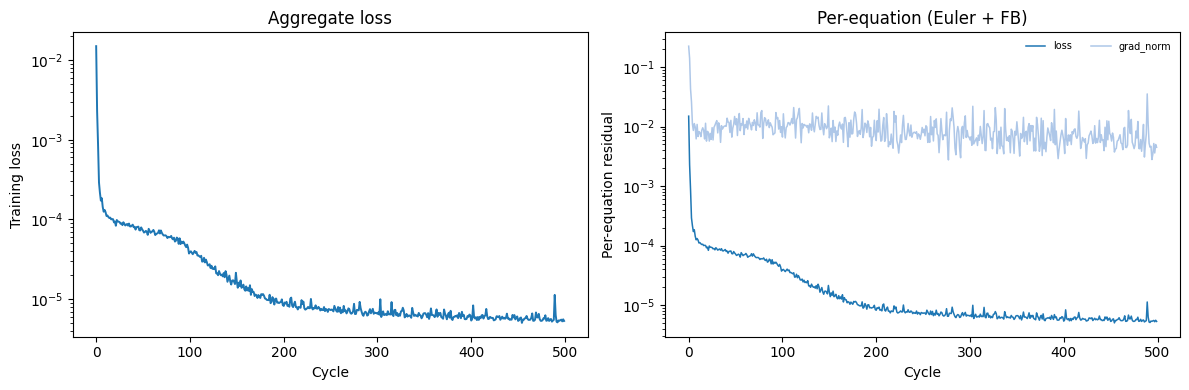

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_loss_curve(history, ax=axes[0])
axes[0].set_title('Aggregate loss')
plot_per_equation_residuals(history, ax=axes[1])
axes[1].set_title('Per-equation (Euler + FB)')
plt.tight_layout()
plt.show()

## 5. The policy across TFP states

This is where the constraint becomes visible: sweep $z$ at fixed $k = k_{ss}$. At low TFP, the optimal $L$ is well below $\bar L$ and the policy matches the unconstrained case. At high TFP, the marginal product of labor is high enough that the agent would want $L > \bar L$ — but the hard cap kicks in, and the policy flattens out at $\bar L$.

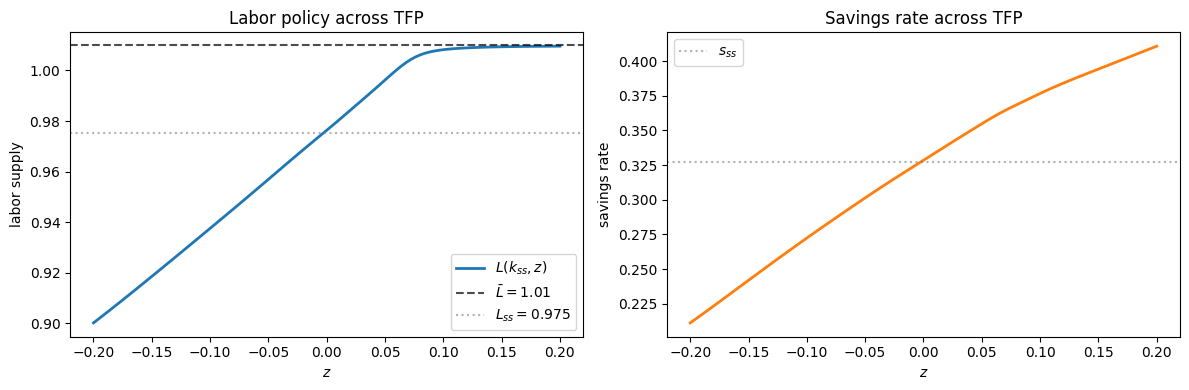

Fraction of grid where constraint binds: 19.8%


In [7]:
L_bar = MODEL.constants['L_bar']
z_grid = jnp.linspace(-0.2, 0.2, 101)
states = jnp.stack([jnp.full_like(z_grid, k_ss), z_grid], axis=1)
pol = np.asarray(policy_net(states))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

z_np = np.asarray(z_grid)
axes[0].plot(z_np, pol[:, 1], lw=2, label='$L(k_{ss}, z)$')
axes[0].axhline(L_bar, color='k', ls='--', alpha=0.7, label=f'$\\bar L = {L_bar}$')
axes[0].axhline(L_ss, color='grey', ls=':', alpha=0.6, label=f'$L_{{ss}} = {L_ss:.3f}$')
axes[0].set_xlabel('$z$'); axes[0].set_ylabel('labor supply')
axes[0].set_title('Labor policy across TFP')
axes[0].legend(loc='lower right')

axes[1].plot(z_np, pol[:, 0], lw=2, color='C1')
axes[1].axhline(float(ss_policy[0]), color='grey', ls=':', alpha=0.6, label='$s_{ss}$')
axes[1].set_xlabel('$z$'); axes[1].set_ylabel('savings rate')
axes[1].set_title('Savings rate across TFP')
axes[1].legend()

plt.tight_layout()
plt.show()

binding_frac = float((pol[:, 1] > L_bar - 1e-3).mean())
print(f'Fraction of grid where constraint binds: {binding_frac:.1%}')

## 6. KKT diagnostics: $a$, $b$, and the FB residual

Decompose the FB residual back into its two arms. At interior states we expect $a \approx 0$, $b > 0$. At binding states we expect $b \approx 0$, $a > 0$. The combined FB residual should be small *everywhere*.

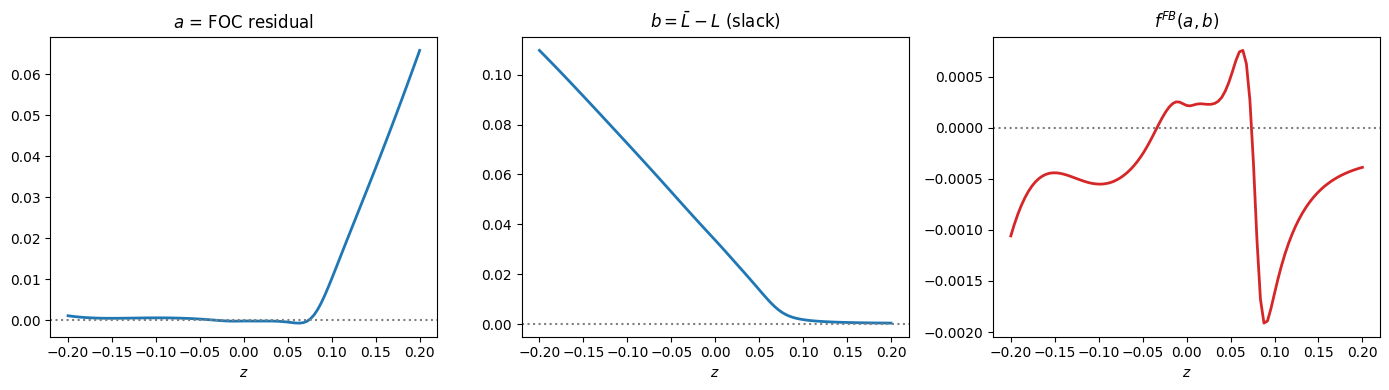

|FB residual| — max: 1.91e-03,  mean: 5.70e-04


In [8]:
from deqn_jax.models.bm_labor_constrained.equations import definitions

C_par = MODEL.constants
defs = definitions(states, policy_net(states), C_par)
L_pred = pol[:, 1]

a_arm = np.asarray(defs['w'] * defs['u_c'] / (C_par['psi'] * L_pred ** C_par['theta']) - 1.0)
b_arm = L_bar - L_pred
fb_val = np.asarray(fischer_burmeister(jnp.asarray(a_arm), jnp.asarray(b_arm)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(z_np, a_arm, lw=2)
axes[0].axhline(0, color='grey', ls=':'); axes[0].set_title('$a$ = FOC residual')
axes[0].set_xlabel('$z$')

axes[1].plot(z_np, b_arm, lw=2)
axes[1].axhline(0, color='grey', ls=':'); axes[1].set_title(r'$b = \bar L - L$ (slack)')
axes[1].set_xlabel('$z$')

axes[2].plot(z_np, fb_val, lw=2, color='C3')
axes[2].axhline(0, color='grey', ls=':'); axes[2].set_title('$f^{FB}(a, b)$')
axes[2].set_xlabel('$z$')

plt.tight_layout()
plt.show()

print(f'|FB residual| — max: {np.abs(fb_val).max():.2e},  mean: {np.abs(fb_val).mean():.2e}')

## 7. IRF with the constraint

An IRF to a +2$\sigma$ TFP shock is large enough to push $L$ against the ceiling. The constrained response in $L$ is flat for a few periods while $z$ mean-reverts back into the interior region.

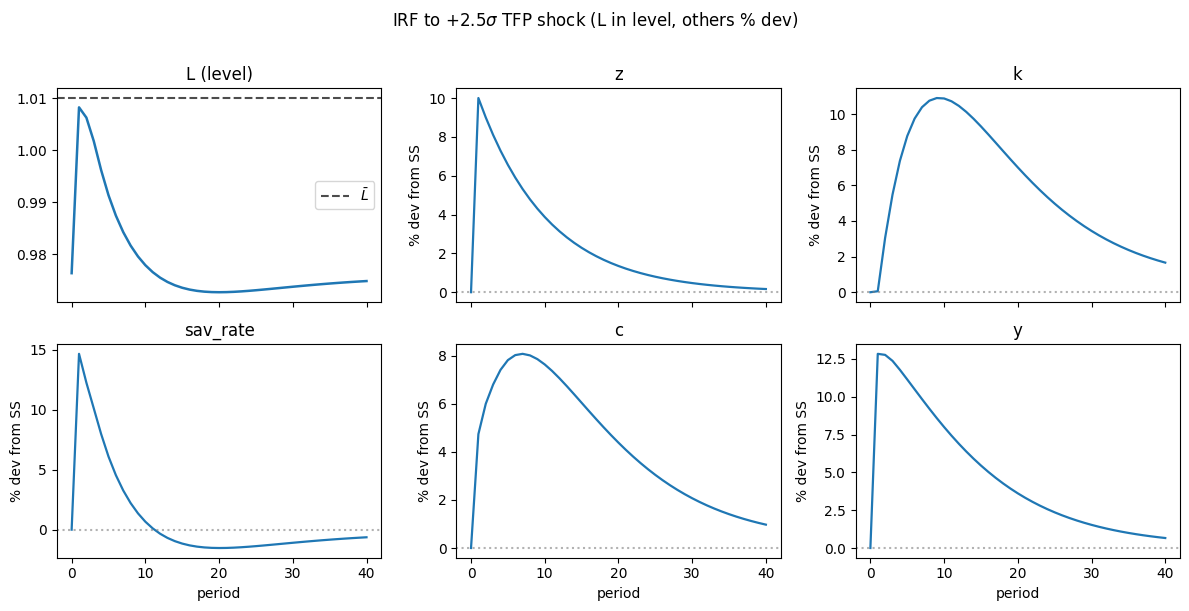

In [9]:
from deqn_jax.irf import run_irf

irf = run_irf(policy_net, MODEL, shock_name='eps_z', shock_size=2.5, horizon=40)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
t = np.asarray(irf['period'])

# L and constraint, in levels to see the ceiling
ax = axes[0, 0]
ax.plot(t, irf['L'], lw=1.8)
ax.axhline(L_bar, color='k', ls='--', alpha=0.7, label='$\\bar L$')
ax.set_title('L (level)'); ax.legend()

# Others in % dev
for ax, var in zip(axes.flat[1:], ['z', 'k', 'sav_rate', 'c', 'y']):
    series = np.asarray(irf[var])
    base = series[0] if abs(series[0]) > 1e-10 else 1.0
    pct = 100.0 * (series - series[0]) / abs(base)
    ax.plot(t, pct, lw=1.6)
    ax.axhline(0, color='grey', ls=':', alpha=0.6)
    ax.set_title(var); ax.set_ylabel('% dev from SS')
for ax in axes[-1]:
    ax.set_xlabel('period')
plt.suptitle('IRF to +2.5$\\sigma$ TFP shock (L in level, others % dev)', y=1.01)
plt.tight_layout()
plt.show()

## 8. Summary

- Added an occasionally-binding upper bound $L \le \bar L = 1.01$ on top of `bm_labor`.
- The **hard** bound is enforced by the network's sigmoid output with a finite `POLICY_UPPER[1]`. The **soft** optimality condition is the Fischer-Burmeister residual $f^{FB}(a, b)$ where $a$ is the original FOC residual and $b = \bar L - L$ is the slack.
- New infrastructure: `src/deqn_jax/models/_complementarity.py` with a single helper `fischer_burmeister(a, b)`. That's all it takes.
- Trained policy: interior across the bulk of the ergodic set; constraint binds in the high-TFP tail; FB residual is $\sim 10^{-3}$ everywhere.

**Next notebook** (`olg_lifecycle_6.ipynb`): the same FB machinery, applied per-age to a 6-generation OLG with borrowing constraints $k'^h \ge 0$. Five FB residuals, five Euler inequalities.

### References
- Azinovic, Gaegauf & Scheidegger (2022), *International Economic Review* 63(4), 1471–1525
